In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, accuracy_score,
                            precision_score, recall_score, f1_score)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
df = pd.read_csv('C:/Users/kotla/CustomerChurnPrediction/data/Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn Info:")
print(df.info())
df.head()

Dataset Shape: (7043, 21)

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data = df.copy()

# Drop customerID (not useful for modeling)
data = data.drop('customerID', axis=1)

# Handle TotalCharges - it's an object type but should be numeric
print("\nUnique values in TotalCharges (first 10):", data['TotalCharges'].unique()[:10])

# Convert TotalCharges to numeric (some are empty strings)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with 0 (these are new customers with 0 tenure)
data['TotalCharges'].fillna(0, inplace=True)

# Convert Churn to binary
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

print("\nMissing values after cleaning:")
print(data.isnull().sum())

print("\nChurn Distribution:")
print(data['Churn'].value_counts())
print(f"\nChurn Rate: {data['Churn'].mean():.2%}")



Unique values in TotalCharges (first 10): <StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95']
Length: 10, dtype: str

Missing values after cleaning:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%


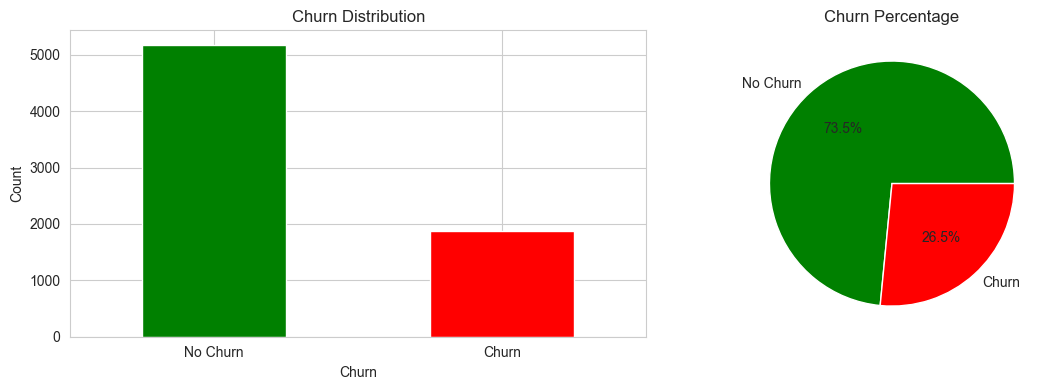

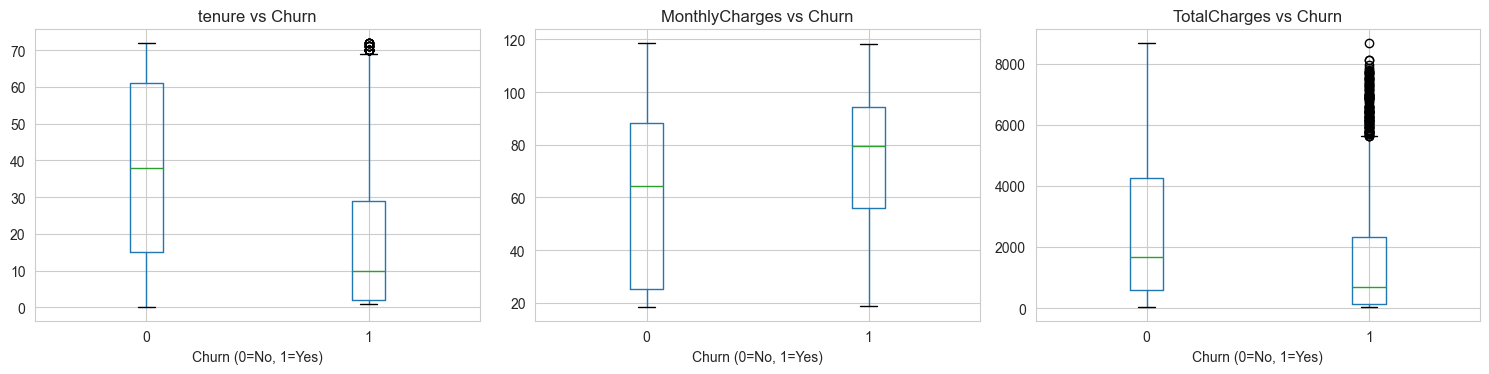

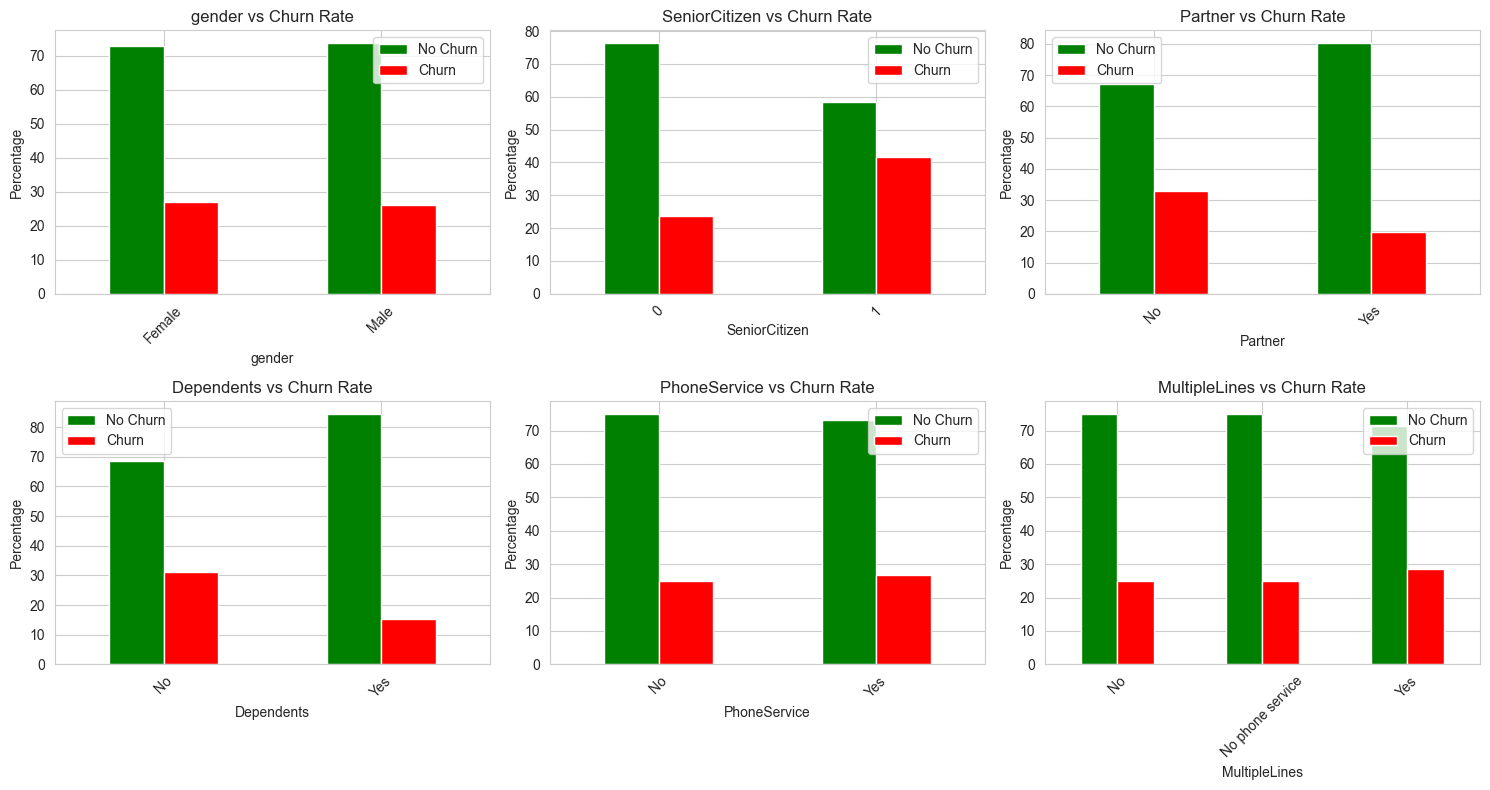


Churn rate by Contract Type:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Churn rate by Tenure Groups:
tenure_group
0-1 year     0.476782
1-2 years    0.287109
2-4 years    0.203890
4+ years     0.095132
Name: Churn, dtype: float64


In [8]:

# STEP 3: EXPLORATORY DATA ANALYSIS


# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
axes[0].set_ylabel('Count')

data['Churn'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], 
                                                  autopct='%1.1f%%',
                                                  colors=['green', 'red'],
                                                  labels=['No Churn', 'Churn'])
axes[1].set_title('Churn Percentage')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

# Numerical features vs Churn
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    data.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Categorical features vs Churn
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

# Plot first 6 categorical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(categorical_cols[:6]):
    ct = pd.crosstab(data[col], data['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['green', 'red'])
    axes[i].set_title(f'{col} vs Churn Rate')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel(col)
    axes[i].legend(['No Churn', 'Churn'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Key insights visualization


# Contract type impact
print("\nChurn rate by Contract Type:")
print(data.groupby('Contract')['Churn'].mean().sort_values(ascending=False))

# Tenure analysis
print("\nChurn rate by Tenure Groups:")
data['tenure_group'] = pd.cut(data['tenure'], bins=[0, 12, 24, 48, 73], 
                               labels=['0-1 year', '1-2 years', '2-4 years', '4+ years'])
print(data.groupby('tenure_group')['Churn'].mean())



In [9]:
model_data = data.copy()
if model_data["Churn"].dtype == "object":
    model_data["Churn"] = model_data["Churn"].map({"Yes": 1, "No": 0})
if "customerID" in model_data.columns:
    model_data = model_data.drop(columns=["customerID"])

X = model_data.drop('Churn', axis=1)
y = model_data['Churn']

# Ensure all columns are numeric types (convert any remaining categorical)
if "TotalCharges" in X.columns:
    X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

X = pd.get_dummies(X, drop_first=True)

# 7) Replace inf values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 8) Fill NaN values using median (numeric only)
X = X.fillna(X.median(numeric_only=True))



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")



Training set: (5634, 33)
Test set: (1409, 33)
Churn rate in train: 26.54%
Churn rate in test: 26.54%


In [11]:
#"CLASS IMBALANCE ANALYSIS"


churn_counts = y_train.value_counts()
print(f"No Churn (0): {churn_counts[0]} ({churn_counts[0]/len(y_train):.1%})")
print(f"Churn (1): {churn_counts[1]} ({churn_counts[1]/len(y_train):.1%})")
print(f"Imbalance Ratio: {churn_counts[0]/churn_counts[1]:.2f}:1")

# Calculate class weights for handling imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Computed Class Weights: {class_weight_dict}")

# Scale pos weight for XGBoost
scale_pos_weight = churn_counts[0] / churn_counts[1]
print(f"Scale Pos Weight (for XGBoost): {scale_pos_weight:.2f}")

No Churn (0): 4139 (73.5%)
Churn (1): 1495 (26.5%)
Imbalance Ratio: 2.77:1
Computed Class Weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}
Scale Pos Weight (for XGBoost): 2.77


In [13]:

#"TRAINING MODELS"


# Dictionary to store models and results
models = {}
results = {}

# 1. LOGISTIC REGRESSION
print("\n Training Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
print(" Logistic Regression trained")

# 2. RANDOM FOREST
print("\n Training Random Forest")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
print(" Random Forest trained")

# 3. XGBOOST
print("\n Training XGBoost")
# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
models['XGBoost'] = xgb_model
print(" XGBoost trained")



 Training Logistic Regression
 Logistic Regression trained

 Training Random Forest
 Random Forest trained

 Training XGBoost
 XGBoost trained


In [14]:
# STEP 6: HYPERPARAMETER TUNING


from sklearn.model_selection import GridSearchCV

# Dictionary to store models and results
models = {}
results = {}

# 1. LOGISTIC REGRESSION with GridSearch
print("\n1. Tuning Logistic Regression...")
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    lr_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
lr_model = lr_grid.best_estimator_
models['Logistic Regression'] = lr_model

print(f" Best params: {lr_grid.best_params_}")
print(f" Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

# 2. RANDOM FOREST with GridSearch
print("\n2. Tuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train)
rf_model = rf_grid.best_estimator_
models['Random Forest'] = rf_model

print(f" Best params: {rf_grid.best_params_}")
print(f" Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

# 3. XGBOOST with GridSearch
print("\n3. Tuning XGBoost...")
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_scaled, y_train)
xgb_model = xgb_grid.best_estimator_
models['XGBoost'] = xgb_model

print(f" Best params: {xgb_grid.best_params_}")
print(f" Best CV ROC-AUC: {xgb_grid.best_score_:.4f}")

print("\n All models tuned!")


1. Tuning Logistic Regression...
 Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
 Best CV ROC-AUC: 0.8466

2. Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
 Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 200}
 Best CV ROC-AUC: 0.8453

3. Tuning XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
 Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
 Best CV ROC-AUC: 0.8465

 All models tuned!


In [16]:
# STEP 7: EVALUATE ALL MODELS



for name, model in models.items():
    
    print(f"{name}")
    
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    # Print metrics
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Logistic Regression
Accuracy:  0.7346
Precision: 0.5000
Recall:    0.7888
F1 Score:  0.6120
ROC-AUC:   0.8408

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409

Random Forest
Accuracy:  0.7630
Precision: 0.5375
Recall:    0.7674
F1 Score:  0.6322
ROC-AUC:   0.8465

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

XGBoost
Accuracy:  0.7530
Precision: 0.5225
Recall:    0.8075
F1 Score:  0.6345
ROC-

MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.734564   0.500000 0.788770  0.612033 0.840781
      Random Forest  0.762952   0.537453 0.767380  0.632159 0.846493
            XGBoost  0.753016   0.522491 0.807487  0.634454 0.846638
BEST PERFORMANCE BY METRIC
Accuracy    : Random Forest        (0.7630)
Precision   : Random Forest        (0.5375)
Recall      : XGBoost              (0.8075)
F1 Score    : XGBoost              (0.6345)
ROC-AUC     : XGBoost              (0.8466)
CLASS IMBALANCE HANDLING CHECK
Note: High Recall means we're catching churners (minority class)
      Balanced Precision/Recall means good handling of imbalance

Logistic Regression:
  Precision (Churn): 0.500
  Recall (Churn):    0.789
  Balance Score:     0.612

Random Forest:
  Precision (Churn): 0.537
  Recall (Churn):    0.767
  Balance Score:     0.632

XGBoost:
  Precision (Churn): 0.522
  Recall (Churn):    0.807
  Balance Score:     0.634


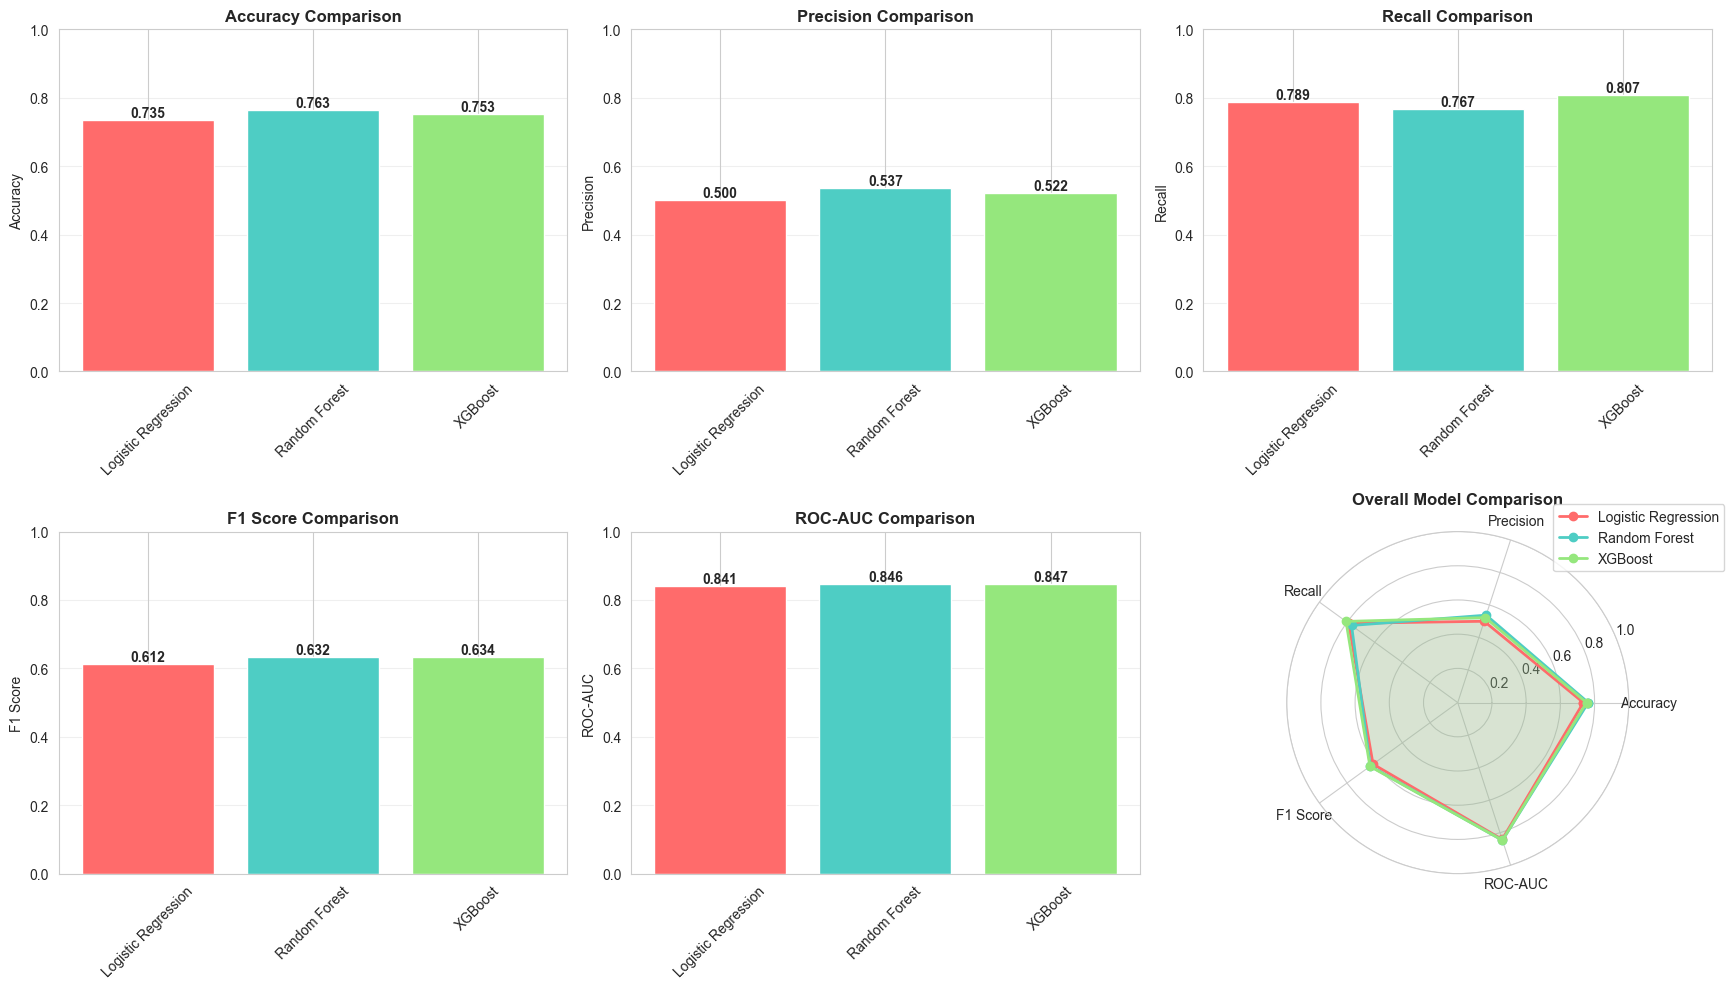

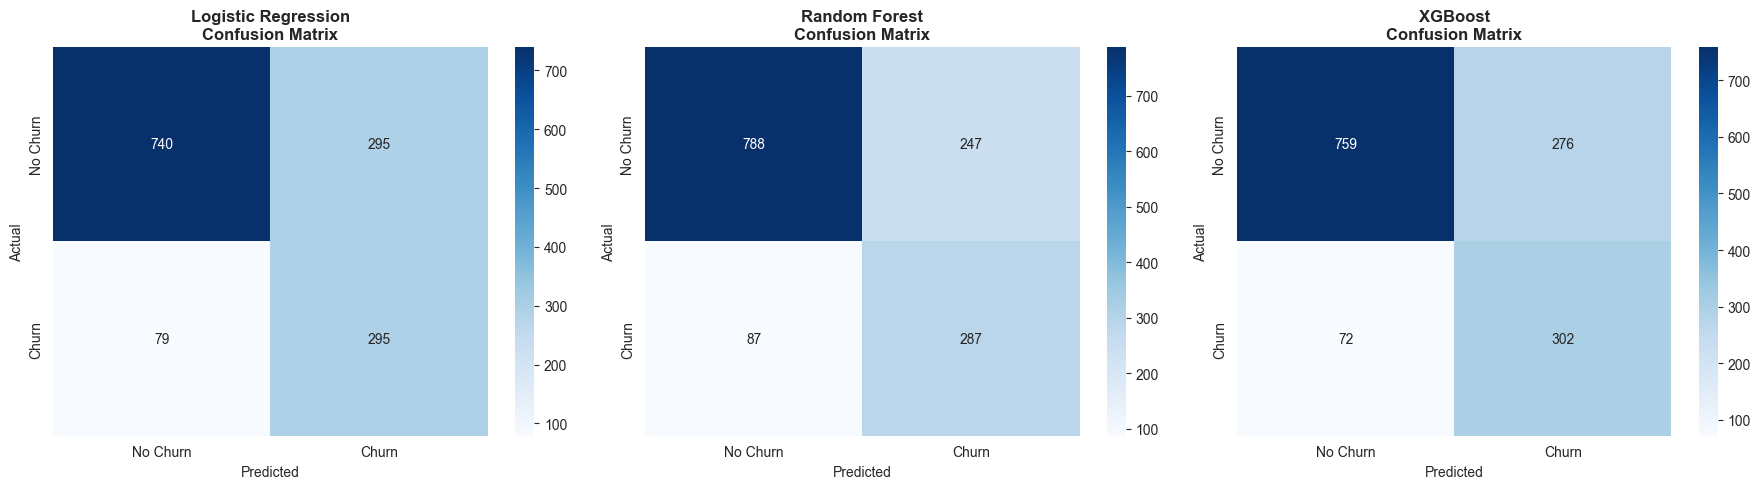

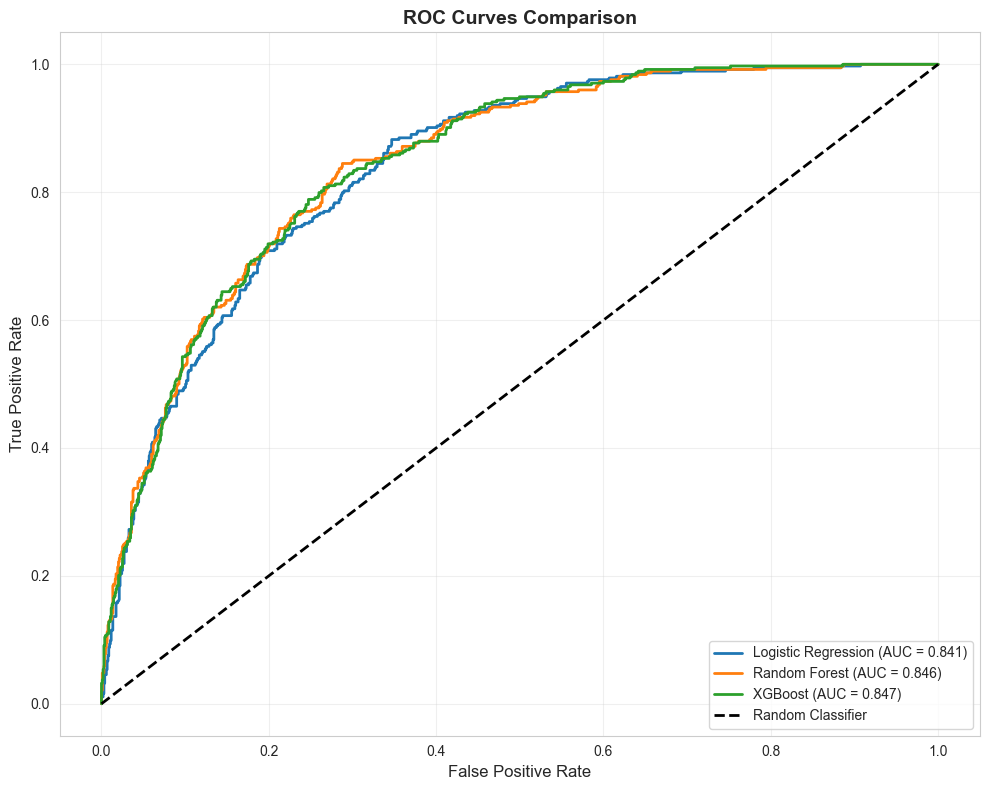

In [18]:
# STEP 8: MODEL COMPARISON VISUALIZATIONS


# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1 Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})


print("MODEL COMPARISON")

print(comparison_df.to_string(index=False))

# Highlight best model for each metric

print("BEST PERFORMANCE BY METRIC")

for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    best_idx = comparison_df[metric].idxmax()
    best_model = comparison_df.loc[best_idx, 'Model']
    best_value = comparison_df.loc[best_idx, metric]
    print(f"{metric:12s}: {best_model:20s} ({best_value:.4f})")

# Check class imbalance handling effectiveness

print("CLASS IMBALANCE HANDLING CHECK")

print("Note: High Recall means we're catching churners (minority class)")
print("      Balanced Precision/Recall means good handling of imbalance")
for name in results.keys():
    precision = results[name]['precision']
    recall = results[name]['recall']
    balance_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f"\n{name}:")
    print(f"  Precision (Churn): {precision:.3f}")
    print(f"  Recall (Churn):    {recall:.3f}")
    print(f"  Balance Score:     {balance_score:.3f}")
    if recall < 0.5:
        print(f"  ⚠️  Warning: Low recall - missing many churners!")

# Bar chart comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors = ['#FF6B6B', '#4ECDC4', '#95E77D']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = comparison_df[metric].values
    bars = ax.bar(comparison_df['Model'], values, color=colors)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}',
                ha='center', va='bottom', fontweight='bold')

# Overall comparison radar chart
axes[5].remove()
ax = plt.subplot(2, 3, 6, projection='polar')

categories = metrics
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for i, model_name in enumerate(comparison_df['Model']):
    values = comparison_df.iloc[i, 1:].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Overall Model Comparison', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ROC Curves Comparison
plt.figure(figsize=(10, 8))

for name in models.keys():
    y_pred_proba = results[name]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = results[name]['roc_auc']
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


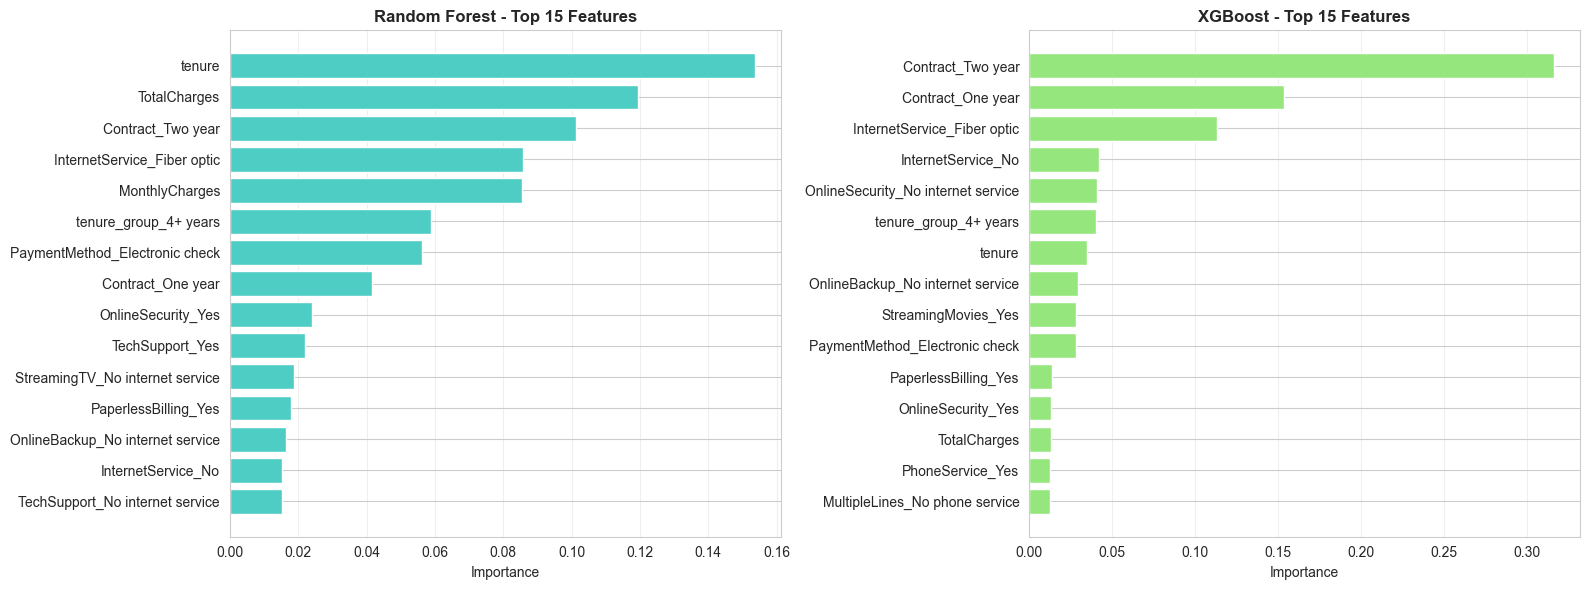

LOGISTIC REGRESSION - TOP 10 COEFFICIENTS
                           feature  coefficient
2                   MonthlyCharges    -2.040637
10     InternetService_Fiber optic     1.260878
1                           tenure    -1.060217
25               Contract_Two year    -0.667373
23             StreamingMovies_Yes     0.467467
21                 StreamingTV_Yes     0.455771
9                MultipleLines_Yes     0.309140
24               Contract_One year    -0.302570
3                     TotalCharges     0.203250
28  PaymentMethod_Electronic check     0.187155


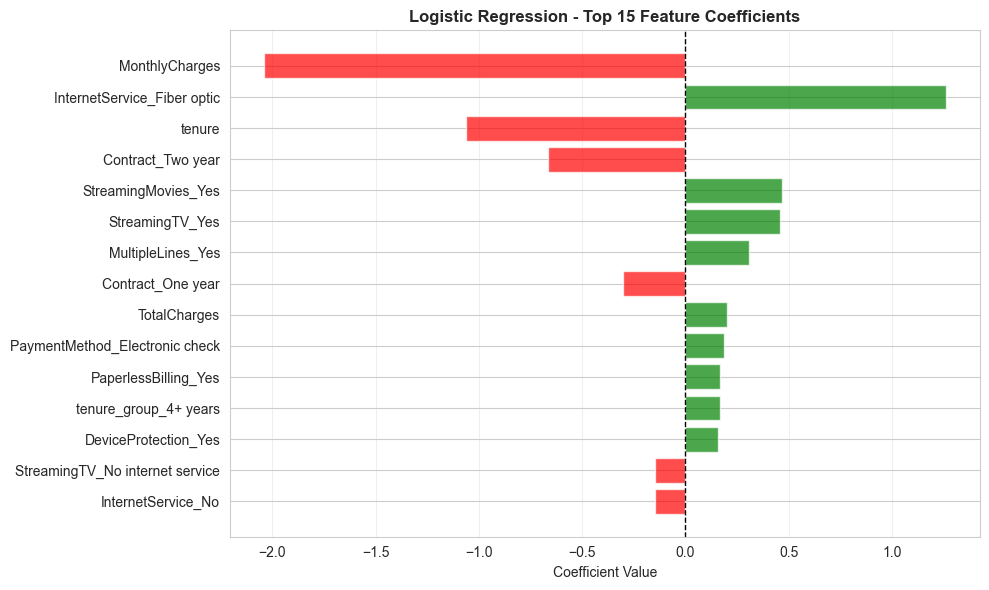

In [20]:
# STEP 9: FEATURE IMPORTANCE (for tree-based models)


# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
top_rf = rf_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['importance'], color='#4ECDC4')
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['feature'])
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 15 Features', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
top_xgb = xgb_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['importance'], color='#95E77D')
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['feature'])
axes[1].set_xlabel('Importance')
axes[1].set_title('XGBoost - Top 15 Features', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Logistic Regression Coefficients
lr_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)


print("LOGISTIC REGRESSION - TOP 10 COEFFICIENTS")

print(lr_coef.head(10))

plt.figure(figsize=(10, 6))
top_coef = lr_coef.head(15)
colors_coef = ['red' if x < 0 else 'green' for x in top_coef['coefficient']]
plt.barh(range(len(top_coef)), top_coef['coefficient'], color=colors_coef, alpha=0.7)
plt.yticks(range(len(top_coef)), top_coef['feature'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression - Top 15 Feature Coefficients', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# STEP 10: SELECT BEST MODEL AND SAVE


# Select best model based on ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = models[best_model_name]
best_roc_auc = results[best_model_name]['roc_auc']


print("BEST MODEL SELECTION")

print(f"Best Model: {best_model_name}")
print(f"ROC-AUC Score: {best_roc_auc:.4f}")

# Save all models
import joblib

for name, model in models.items():
    model_filename = name.lower().replace(' ', '_') + '_model.pkl'
    joblib.dump(model, model_filename)
    print(f"✓ Saved: {model_filename}")

# Save the best model separately for easy access
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

# Save model comparison
comparison_df.to_csv('model_comparison.csv', index=False)

# Save cleaned data for segmentation
model_data.to_csv('cleaned_telco_data.csv', index=False)

print("\n✓ Best model saved as 'churn_model.pkl'")
print("✓ All models saved!")
print("✓ Cleaned data saved!")
print("✓ Week 1 Complete!")
print("\n Summary:")
print(f"   - Best Model: {best_model_name}")
print(f"   - Best ROC-AUC: {best_roc_auc:.3f}")
print(f"   - Features: {len(X.columns)}")


BEST MODEL SELECTION
Best Model: XGBoost
ROC-AUC Score: 0.8466
✓ Saved: logistic_regression_model.pkl
✓ Saved: random_forest_model.pkl
✓ Saved: xgboost_model.pkl

✓ Best model saved as 'churn_model.pkl'
✓ All models saved!
✓ Cleaned data saved!
✓ Week 1 Complete!

 Summary:
   - Best Model: XGBoost
   - Best ROC-AUC: 0.847
   - Features: 33


In [23]:
data = pd.read_csv('cleaned_telco_data.csv')
print("Data loaded:", data.shape)
print(f"Churn rate: {data['Churn'].mean():.2%}")

Data loaded: (7043, 21)
Churn rate: 26.54%


In [24]:
# STEP 2: SELECT FEATURES FOR CLUSTERING

print(data.columns.tolist())
# Create num_services feature from service columns
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

data['num_services'] = (data[service_cols] == 'Yes').sum(axis=1)

# We'll use behavioral and value features for segmentation
clustering_features = [
    'tenure',                    # How long they've been customers
    'MonthlyCharges',           # Monthly spend
    'TotalCharges',             # Total lifetime value
    'num_services',             # Number of services used
    'Contract',                 # Contract type (encoded)
    'InternetService',          # Internet service type
    'PaymentMethod',            # Payment method
    'PaperlessBilling'          # Billing preference
]

# Create clustering dataset
cluster_data = data[clustering_features].copy()

print("\nFeatures for clustering:")
for feat in clustering_features:
    print(f"  - {feat}")


# STEP 3: SCALE FEATURES (FORCE 8 COLUMNS VERSION)

from sklearn.preprocessing import StandardScaler
import pandas as pd

cluster_data = cluster_data.copy()

# Ensure numeric columns are numeric
cluster_data["TotalCharges"] = pd.to_numeric(
    cluster_data["TotalCharges"], errors="coerce"
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]
cat_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

# Fill numeric NaNs
cluster_data[num_cols] = cluster_data[num_cols].fillna(
    cluster_data[num_cols].median()
)

#  Encode categorical columns as integers (1 column each)
for col in cat_cols:
    cluster_data[col] = cluster_data[col].astype("category").cat.codes

# Scale everything
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data[num_cols + cat_cols])

print("Final scaled data shape:", cluster_scaled.shape)



['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']

Features for clustering:
  - tenure
  - MonthlyCharges
  - TotalCharges
  - num_services
  - Contract
  - InternetService
  - PaymentMethod
  - PaperlessBilling
Final scaled data shape: (7043, 8)


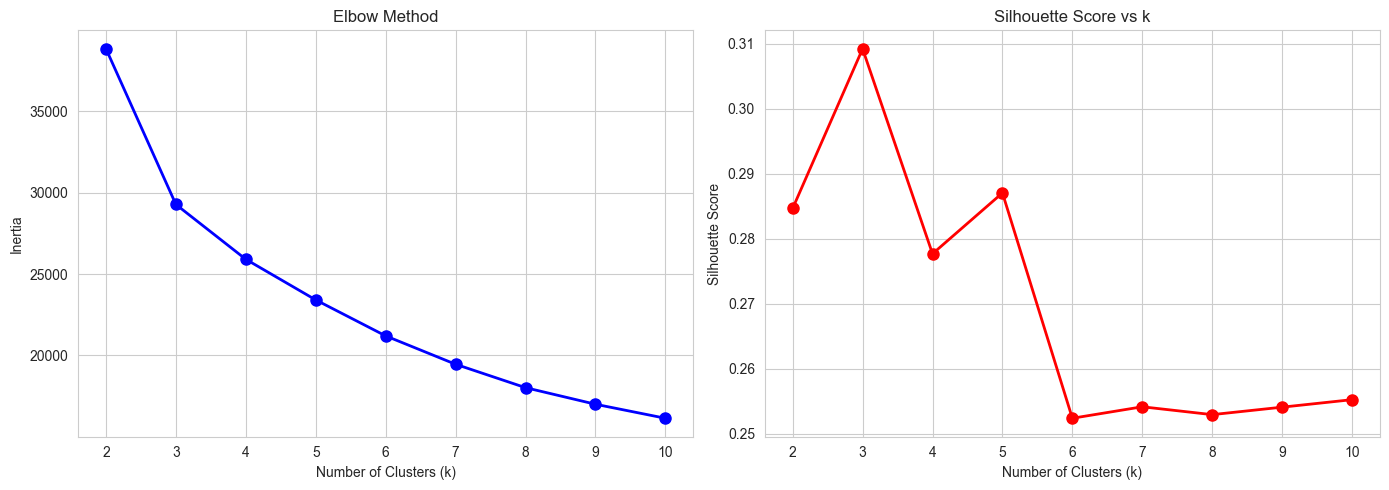


Silhouette Scores:
  k=2: 0.285
  k=3: 0.309
  k=4: 0.278
  k=5: 0.287
  k=6: 0.252
  k=7: 0.254
  k=8: 0.253
  k=9: 0.254
  k=10: 0.255


In [25]:
# STEP 4: FIND OPTIMAL NUMBER OF CLUSTERS

# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  k={k}: {score:.3f}")


In [26]:
# STEP 5: CREATE SEGMENTS (k=4 or k=5)


# Choose optimal k (usually 4 or 5 works well)
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Segment'] = kmeans.fit_predict(cluster_scaled)

print(f"\n Created {optimal_k} customer segments")
print("\nSegment Distribution:")
print(data['Segment'].value_counts().sort_index())



 Created 4 customer segments

Segment Distribution:
Segment
0    1979
1    2348
2    1190
3    1526
Name: count, dtype: int64


In [27]:
# STEP 6: ANALYZE SEGMENTS


# Analyze each segment
segment_summary = data.groupby('Segment').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'num_services': 'mean',
    'Churn': 'mean'
}).round(2)

segment_summary['Count'] = data.groupby('Segment').size()
segment_summary['Churn_Rate_%'] = (segment_summary['Churn'] * 100).round(1)

print("\nSegment Statistics:")
print(segment_summary)



Segment Statistics:
         tenure  MonthlyCharges  TotalCharges  num_services  Churn  Count  \
Segment                                                                     
0         59.78           90.50       5402.25          5.73   0.13   1979   
1         17.03           72.43       1236.93          3.00   0.49   2348   
2         19.39           62.85       1223.37          2.87   0.29   1190   
3         30.55           21.08        665.22          1.22   0.07   1526   

         Churn_Rate_%  
Segment                
0                13.0  
1                49.0  
2                29.0  
3                 7.0  


In [33]:
# STEP 7: NAME THE SEGMENTS


# Analyze characteristics to name segments
segment_names = {}

for seg in range(optimal_k):
    seg_data = data[data['Segment'] == seg]
    
    avg_tenure = seg_data['tenure'].mean()
    avg_charges = seg_data['MonthlyCharges'].mean()
    avg_services = seg_data['num_services'].mean()
    churn_rate = seg_data['Churn'].mean()
    
    # Name based on characteristics
    if avg_tenure < 20 and churn_rate > 0.4:
        name = "At-Risk Newcomers"
    elif avg_tenure > 50 and churn_rate < 0.15:
        name = "Loyal Champions"
    elif avg_charges > 55 and avg_services > 2.5:
        name = "High-Value Users"
    elif avg_charges < 40 and avg_services < 3:
        name = "Budget Conscious"
    else:
        name = f"Segment {seg}"
    
    segment_names[seg] = name
    
    print(f"\n{name} (Segment {seg}):")
    print(f" Avg Tenure: {avg_tenure:.1f} months")
    print(f" Avg Monthly Charges: ${avg_charges:.2f}")
    print(f" Avg Services: {avg_services:.1f}")
    print(f" Churn Rate: {churn_rate:.1%}")
    print(f" Size: {len(seg_data)} customers ({len(seg_data)/len(data):.1%})")

# Add segment names to data
data['Segment_Name'] = data['Segment'].map(segment_names)



Loyal Champions (Segment 0):
 Avg Tenure: 59.8 months
 Avg Monthly Charges: $90.50
 Avg Services: 5.7
 Churn Rate: 13.3%
 Size: 1979 customers (28.1%)

At-Risk Newcomers (Segment 1):
 Avg Tenure: 17.0 months
 Avg Monthly Charges: $72.43
 Avg Services: 3.0
 Churn Rate: 48.9%
 Size: 2348 customers (33.3%)

High-Value Users (Segment 2):
 Avg Tenure: 19.4 months
 Avg Monthly Charges: $62.85
 Avg Services: 2.9
 Churn Rate: 29.0%
 Size: 1190 customers (16.9%)

Budget Conscious (Segment 3):
 Avg Tenure: 30.5 months
 Avg Monthly Charges: $21.08
 Avg Services: 1.2
 Churn Rate: 7.4%
 Size: 1526 customers (21.7%)


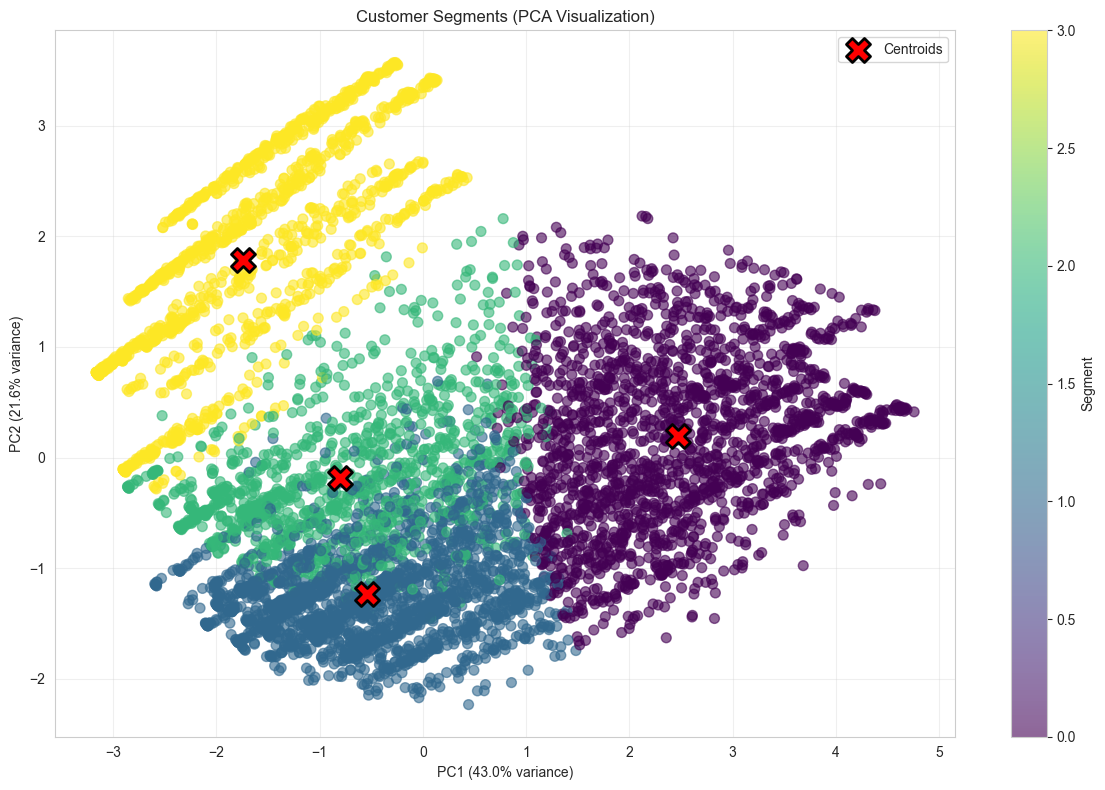

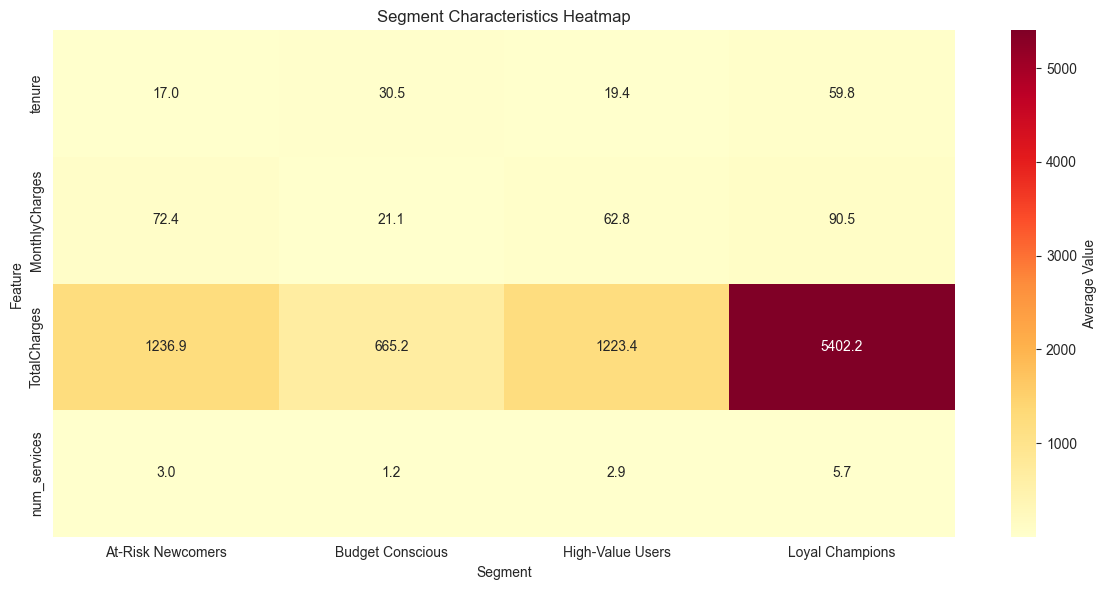

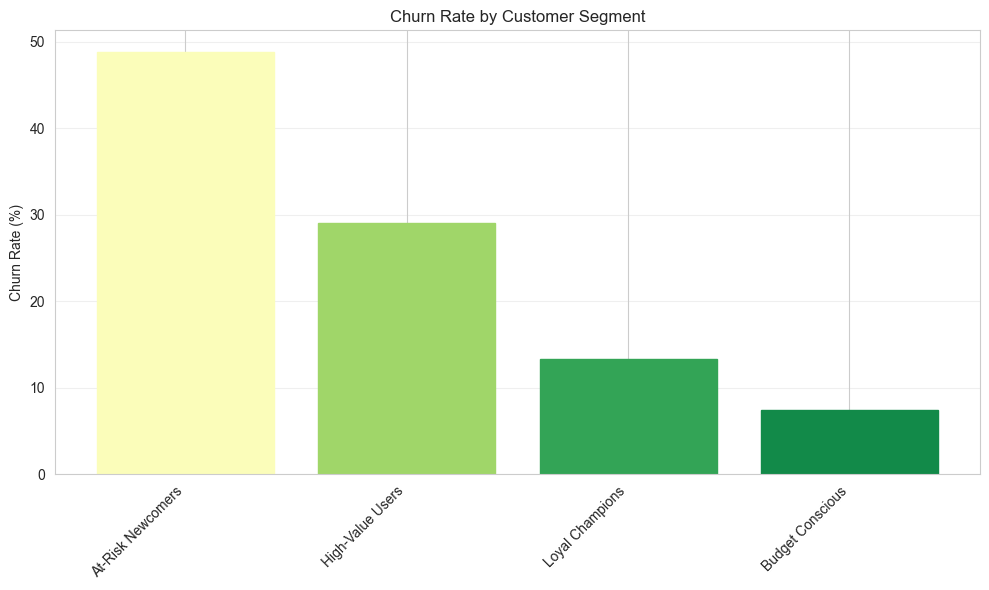

In [34]:
# STEP 8: VISUALIZE SEGMENTS


# 2D visualization using PCA
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1], 
                     c=data['Segment'], cmap='viridis', 
                     alpha=0.6, s=50)

# Add centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Centroids')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Customer Segments (PCA Visualization)')
plt.colorbar(scatter, label='Segment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Segment characteristics heatmap
segment_chars = data.groupby('Segment_Name')[clustering_features].mean(numeric_only=True)

plt.figure(figsize=(12, 6))
sns.heatmap(segment_chars.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Value'})
plt.title('Segment Characteristics Heatmap')
plt.xlabel('Segment')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Churn rate by segment
plt.figure(figsize=(10, 6))
churn_by_segment = data.groupby('Segment_Name')['Churn'].mean().sort_values(ascending=False)
bars = plt.bar(range(len(churn_by_segment)), churn_by_segment.values * 100)

# Color bars by churn rate
colors = plt.cm.RdYlGn_r(churn_by_segment.values)
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xticks(range(len(churn_by_segment)), churn_by_segment.index, rotation=45, ha='right')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# STEP 9: SEGMENT PROFILES FOR INTERVENTIONS



print("INTERVENTION RECOMMENDATIONS BY SEGMENT")


for seg in range(optimal_k):
    seg_data = data[data['Segment'] == seg]
    name = segment_names[seg]
    
    print(f"\n{name}:")
    print(f"  Size: {len(seg_data)} ({len(seg_data)/len(data):.1%})")
    print(f"  Churn Risk: {seg_data['Churn'].mean():.1%}")
    print(f"  Avg Monthly Value: ${seg_data['MonthlyCharges'].mean():.2f}")
    print(f"  Avg Tenure: {seg_data['tenure'].mean():.1f} months")
    
    # Suggest intervention based on profile
    churn_rate = seg_data['Churn'].mean()
    avg_charges = seg_data['MonthlyCharges'].mean()
    avg_tenure = seg_data['tenure'].mean()
    
    if churn_rate > 0.4 and avg_tenure < 20:
        intervention = " Onboarding support + feature tutorials"
    elif churn_rate > 0.3 and avg_charges > 70:
        intervention = " Loyalty rewards + premium support"
    elif churn_rate > 0.25 and avg_charges < 40:
        intervention = " Targeted discounts (10-15%)"
    elif churn_rate < 0.15:
        intervention = " Minimal - focus on retention, upsell opportunities"
    else:
        intervention = " Proactive customer success outreach"
    
    print(f"  Suggested Intervention: {intervention}")


INTERVENTION RECOMMENDATIONS BY SEGMENT

Loyal Champions:
  Size: 1979 (28.1%)
  Churn Risk: 13.3%
  Avg Monthly Value: $90.50
  Avg Tenure: 59.8 months
  Suggested Intervention:  Minimal - focus on retention, upsell opportunities

At-Risk Newcomers:
  Size: 2348 (33.3%)
  Churn Risk: 48.9%
  Avg Monthly Value: $72.43
  Avg Tenure: 17.0 months
  Suggested Intervention:  Onboarding support + feature tutorials

High-Value Users:
  Size: 1190 (16.9%)
  Churn Risk: 29.0%
  Avg Monthly Value: $62.85
  Avg Tenure: 19.4 months
  Suggested Intervention:  Proactive customer success outreach

Budget Conscious:
  Size: 1526 (21.7%)
  Churn Risk: 7.4%
  Avg Monthly Value: $21.08
  Avg Tenure: 30.5 months
  Suggested Intervention:  Minimal - focus on retention, upsell opportunities


In [36]:
# STEP 10: SAVE RESULTS


# Save segmented data
data.to_csv('segmented_telco_data.csv', index=False)

# Save segment profiles
segment_summary.to_csv('segment_profiles.csv')

# Save for Week 3
import joblib
joblib.dump(segment_names, 'segment_names.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'clustering_scaler.pkl')

print("\n Segmented data saved!")
print(" Segment profiles saved!")


 Segmented data saved!
 Segment profiles saved!


In [37]:
data = pd.read_csv('segmented_telco_data.csv')
segment_names = joblib.load('segment_names.pkl')
churn_model = joblib.load('churn_model.pkl')
scaler = joblib.load('scaler.pkl')

print("Data loaded:", data.shape)
print(f"Total customers: {len(data)}")
print(f"Overall churn rate: {data['Churn'].mean():.2%}")


Data loaded: (7043, 24)
Total customers: 7043
Overall churn rate: 26.54%


In [39]:
# STEP 2: DEFINE INTERVENTIONS


interventions = {
    'no_action': {
        'name': 'No Action',
        'cost': 0,
        'effectiveness': 0,  # No change in churn
        'description': 'Do nothing - baseline'
    },
    'discount_10': {
        'name': '10% Discount',
        'cost_per_customer': lambda row: row['MonthlyCharges'] * 0.10 * 3,  # 3 months
        'effectiveness': 0.15,  # Reduces churn by 15%
        'description': '10% off for 3 months'
    },
    'discount_20': {
        'name': '20% Discount',
        'cost_per_customer': lambda row: row['MonthlyCharges'] * 0.20 * 3,
        'effectiveness': 0.30,  # Reduces churn by 30%
        'description': '20% off for 3 months'
    },
    'feature_tutorial': {
        'name': 'Feature Tutorial',
        'cost_per_customer': lambda row: 15,  # Fixed cost
        'effectiveness': 0.20,  # Reduces churn by 20%
        'description': 'Personalized onboarding session'
    },
    'premium_support': {
        'name': 'Premium Support',
        'cost_per_customer': lambda row: 50,  # Customer success call
        'effectiveness': 0.25,  # Reduces churn by 25%
        'description': 'Dedicated support agent'
    },
    'loyalty_reward': {
        'name': 'Loyalty Reward',
        'cost_per_customer': lambda row: 30,  # One-time reward
        'effectiveness': 0.18,  # Reduces churn by 18%
        'description': 'Gift card or service upgrade'
    }
}


print("AVAILABLE INTERVENTIONS")

for key, inter in interventions.items():
    if key != 'no_action':
        print(f"\n{inter['name']}:")
        print(f"  Description: {inter['description']}")
        print(f"  Effectiveness: Reduces churn by {inter['effectiveness']*100:.0f}%")


AVAILABLE INTERVENTIONS

10% Discount:
  Description: 10% off for 3 months
  Effectiveness: Reduces churn by 15%

20% Discount:
  Description: 20% off for 3 months
  Effectiveness: Reduces churn by 30%

Feature Tutorial:
  Description: Personalized onboarding session
  Effectiveness: Reduces churn by 20%

Premium Support:
  Description: Dedicated support agent
  Effectiveness: Reduces churn by 25%

Loyalty Reward:
  Description: Gift card or service upgrade
  Effectiveness: Reduces churn by 18%


In [46]:
# STEP 3: ASSIGN INTERVENTIONS TO SEGMENTS


# Define intervention strategy for each segment
segment_interventions = {}

for seg_id, seg_name in segment_names.items():
    seg_data = data[data['Segment'] == seg_id]
    avg_churn = seg_data['Churn'].mean()
    avg_charges = seg_data['MonthlyCharges'].mean()
    avg_tenure = seg_data['tenure'].mean()
    
    # Decision logic for intervention assignment
    if 'Newcomer' in seg_name or (avg_tenure < 20 and avg_churn > 0.4):
        intervention = 'feature_tutorial'
    elif 'High-Value' in seg_name or avg_charges > 70:
        intervention = 'premium_support'
    elif 'Budget' in seg_name or avg_charges < 40:
        intervention = 'discount_10'
    elif 'Loyal' in seg_name and avg_churn < 0.15:
        intervention = 'no_action'  # Low risk, don't spend
    else:
        intervention = 'discount_20'
    
    segment_interventions[seg_name] = intervention
    
    print(f"\n{seg_name}:")
    print(f"  Churn Risk: {avg_churn:.1%}")
    print(f"  Assigned Intervention: {interventions[intervention]['name']}")



# Add intervention to data
data['Assigned_Intervention'] = data['Segment_Name'].map(segment_interventions)



data['Intervention_Cost'] = data.apply(get_intervention_cost, axis=1)
print(f"\nIntervention costs calculated. Sample: {data['Intervention_Cost'].head()}")



Loyal Champions:
  Churn Risk: 13.3%
  Assigned Intervention: Premium Support

At-Risk Newcomers:
  Churn Risk: 48.9%
  Assigned Intervention: Feature Tutorial

High-Value Users:
  Churn Risk: 29.0%
  Assigned Intervention: Premium Support

Budget Conscious:
  Churn Risk: 7.4%
  Assigned Intervention: 10% Discount

Intervention costs calculated. Sample: 0    15.0
1    50.0
2    15.0
3    50.0
4    15.0
Name: Intervention_Cost, dtype: float64


In [ ]:
# STEP 8: SAVE RESULTS


# Save intervention data
data.to_csv('intervention_results.csv', index=False)

# Save summary
summary = {
    'total_customers': len(data),
    'high_risk_customers': data['High_Risk'].sum(),
    'total_intervention_cost': total_cost,
    'total_prevented_loss': total_prevented_loss,
    'net_benefit': total_net_benefit,
    'roi_percentage': (total_net_benefit / total_cost * 100) if total_cost > 0 else 0
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('intervention_summary.csv', index=False)

segment_roi.to_csv('segment_roi.csv')

print(f"\n Intervention results saved!")
print(f" ROI analysis saved!")


✓ Intervention results saved!
✓ ROI analysis saved!
